<a href="https://colab.research.google.com/github/hoffera/PDI-Opera-es_Pontuais_e_Filtragem_Espacial/blob/main/Projeto_M1_%E2%80%93_Opera%C3%A7%C3%B5es_Pontuais_e_Filtragem_Espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage.util import random_noise
import matplotlib.pyplot as plt

# 1 - Preparação das imagens:

## Metricas

In [ ]:
def mse(imgA, imgB):
    err = np.sum((imgA.astype('float') - imgB.astype('float')) ** 2)
    err /= float(imgA.shape[0] * imgA.shape[1])
    return err

def psnr(org, comp):
    mse_val = np.mean((org - comp) ** 2)
    if mse_val == 0:
        return 100
    max_pixel = 255.0
    psnr_val = 20 * np.log10(max_pixel / np.sqrt(mse_val))
    return psnr_val

## Importar imagem


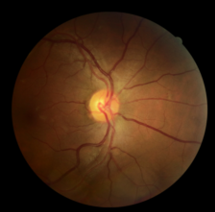

In [ ]:
#abria a imagem
imagem = cv2.imread('/content/fundus_5.png',1)
cv2_imshow(imagem)

## Conversão ponderada

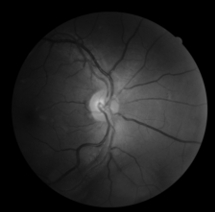

In [ ]:

B, G, R = cv2.split(imagem)
img_grayscale_pondered = 0.299*B+0.587*G+0.114*R

img_grayscale_pondered = np.array(img_grayscale_pondered, dtype=np.uint8)
cv2_imshow(img_grayscale_pondered)

## **Sal e pimenta**


In [ ]:
# Aplicar ruído
imagem_original = img_grayscale_pondered.copy()
imagem_sal_pimenta = (random_noise(img_grayscale_pondered / 255.0, mode='s&p', amount=0.02) * 255).astype(np.uint8)

## Calcular métricas

In [ ]:
mse_val = mse(imagem_original, imagem_sal_pimenta)
psnr_val = psnr(imagem_original, imagem_sal_pimenta)

## Imagem Original Colorida

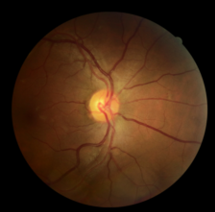

In [ ]:
cv2_imshow(imagem)

## Imagem em Escala de Cinza

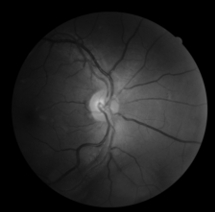

In [ ]:
cv2_imshow(img_grayscale_pondered)

## Imagem com Ruído (Sal e Pimenta)

Imagem com Ruído
MSE: 571.01, PSNR: 46.05 dB


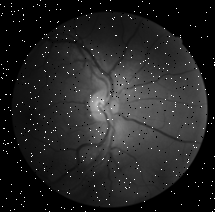

In [ ]:
print(f'Imagem com Ruído\nMSE: {mse_val:.2f}, PSNR: {psnr_val:.2f} dB')
cv2_imshow(imagem_sal_pimenta)

# 2 - Pré-processamento:

## Equalização de histograma imagem Sal pimenta

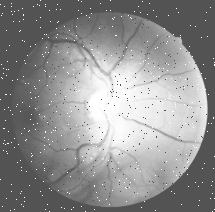

In [ ]:
f_eq = np.round(cdf * 255).astype(int)
img_eq = f_eq[imagem_sal_pimenta]

cv2_imshow(img_eq)


## Correção gama

In [ ]:
#gamma
c = 1 # 255/(np.log(1 + np.max(img_in)))
gamma = 0.5

#img_gamma = np.array(c*255**(img_in/255) ** gamma, dtype = np.uint8)
img_gamma2 = np.array(c*255*(img_eq/255)**gamma, dtype = np.uint8)


# 3 - Redução de ruído

In [ ]:
def gauss_create(sigma=1, size_x=3, size_y=3):
    '''
    Create normal (gaussian) distribuiton
    '''
    x, y = np.meshgrid(np.linspace(-1,1,size_x), np.linspace(-1,1,size_y))
    calc = 1/((2*np.pi*(sigma**2)))
    exp = np.exp(-(((x**2) + (y**2))/(2*(sigma**2))))

    return exp*calc

In [ ]:
def add_padding(img, padding_height, padding_width):
    n, m = img.shape

    padded_img = np.zeros((n + padding_height * 2, m + padding_width * 2))
    padded_img[padding_height : n + padding_height, padding_width : m + padding_width] = img

    return padded_img

In [ ]:
def bubble_sort(arr):

    # Outer loop to iterate through the list n times
    for n in range(len(arr) - 1, 0, -1):

        # Inner loop to compare adjacent elements
        for i in range(n):
            if arr[i] > arr[i + 1]:

                # Swap elements if they are in the wrong order
                swapped = True
                arr[i], arr[i + 1] = arr[i + 1], arr[i]
    return arr

In [ ]:
def conv2d(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img

    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output

    # Perform convolution
    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    output[i_img, j_img] = output[i_img, j_img] + (padded_img[i_img+i_kernel, j_img+j_kernel] * kernel[i_kernel, j_kernel])  # Atribui valor à variável output[i, j]
            output[i_img, j_img] = int(output[i_img, j_img])

    return np.array(output, dtype=np.uint8)

In [ ]:
def medianFilter(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img
    else:
        padded_img = img
    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output
    kernel_vectorized = np.zeros(k_height*k_width)
    #print(kernel_vectorized)
    # Perform convolution
    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            i_vector = 0
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    kernel_vectorized[i_vector] = padded_img[i_img+i_kernel, j_img+j_kernel]  # Atribui valor à variável output[i, j]
                    i_vector+=1
            kernel_vectorized = bubble_sort(kernel_vectorized)
            median_index = int(((k_height*k_width)/2)+1)
            output[i_img, j_img] = int(kernel_vectorized[median_index])

    return np.array(output, dtype=np.uint8)

###  Filtro Mediana

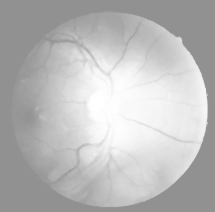

In [ ]:
mean_3x3 = np.ones((3, 3))/9

img_mediana = medianFilter(img_gamma2, mean_3x3, padding=True)

cv2_imshow(img_mediana)

### Gaussiano


In [ ]:
# gaus_3x3 = gauss_create(sigma=1, size_x=3, size_y=3)

# img_mean3 = conv2d(img_gamma2, gaus_3x3, padding=True)


# plt.figure(figsize=figsize)
# plt.imshow(img_mean3, cmap="gray")
# plt.title("Resultado gaussiano")
# plt.show()


# Realce de bordas

## Filtro Laplaciano

In [ ]:
def conv2d_sharpening(img, kernel, padding=True):
    # Get dimensions of the kernel
    k_height, k_width = kernel.shape  # Atribui valor à variável k_height, k_width

    # Get dimensions of the image
    img_height, img_width = img.shape  # Atribui valor à variável img_height, img_width

    # Calculate padding required
    pad_height = k_height // 2  # Atribui valor à variável pad_height
    pad_width = k_width // 2  # Atribui valor à variável pad_width

    # Create a padded version of the image to handle edges
    if padding == True:
        padded_img = add_padding(img, pad_height, pad_width)  # Atribui valor à variável padded_img

    #print(padded_img)

    # Initialize an output image with zeros
    output = np.zeros((img_height, img_width), dtype=float)  # Atribui valor à variável output

    # Perform convolution
    for i_img in range(img_height):  # Loop usando i
        for j_img in range(img_width):  # Loop usando j
            #calcula kernel
            for i_kernel in range(k_height):
                for j_kernel in range(k_width):
                    output[i_img, j_img] = output[i_img, j_img] + (padded_img[i_img+i_kernel, j_img+j_kernel] * kernel[i_kernel, j_kernel])  # Atribui valor à variável output[i, j]
            output[i_img, j_img] = int(output[i_img, j_img])

    return np.array(output, dtype=np.float32)

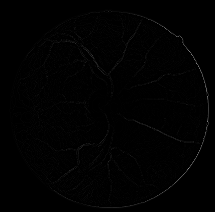

In [ ]:
kernel_laplaciano = np.array(([0,1,0],[1,-4,1],[0,1,0]))

laplaciano = conv2d_sharpening(img_mediana, kernel_laplaciano)
cv2_imshow(laplaciano)

## Operador de Sobel

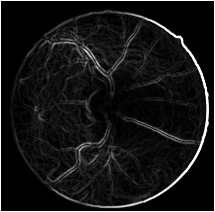

In [ ]:
kernel_sobel_1 = np.array(([-1,-2,-1],[0,0,0],[1,2,1]))
kernel_sobel_2 = np.array(([-1,0,1],[-2,0,2],[-1,0,1]))

img_sobel_1 = conv2d_sharpening(img_mediana, kernel_sobel_1)
img_sobel_2 = conv2d_sharpening(img_mediana, kernel_sobel_2)

img_sobel = np.abs(img_sobel_1)+np.abs(img_sobel_2)
cv2_imshow(img_sobel)


# Ajuste final (High-Boost Filtering)

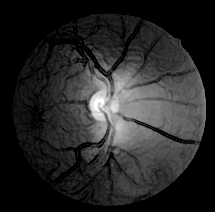

In [ ]:
k = 1.5
img_Highboost = k * img_grayscale_pondered - img_sobel

cv2_imshow(img_Highboost)